# Notebook 2 — K-Means Clustering (Spatial Quality Labels)

## COS40007 Artificial Intelligence Engineering — Theme 5

**Goal:** Cluster 5G grid squares into 3 quality tiers (Poor / Medium / Good)
using K-Means on spatial aggregates of network-quality features.

| Step | Task |
|------|------|
| 0 | Environment & paths |
| 1 | Load `cleaned_5g_data.csv` from Notebook 1 |
| 2 | Reconstruct base features & aggregate per `square_id` |
| 3 | K-Means (k=3) + deterministic label mapping |
| 4 | Evaluation & visualisation (spatial, scatter, PCA) |
| 5 | Export `map_data.csv` + model artefacts |

**Frontend contract:** `backend/data/map_data.csv` with columns
`lat`, `lng`, `cluster` (∈ {0, 1, 2}).

**Note on feature availability:**
Notebook 1's feature-selection step (>0.95 correlation) dropped several
base columns (`download_mbps`, `upload_mbps`, `avg_latency`).
We reconstruct them from surviving proxies:
- `download_mbps` ← `np.expm1(log_download)`
- `avg_latency`   ← `avg_latency_lag1` (mean per square is nearly identical)
- `cwnd`          ← raw `CWnd` column (survived selection)

---
## Step 0 — Environment & Project Paths

In [5]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")

BASE_DIR    = Path(".")
DATA_DIR    = BASE_DIR / "data"
OUTPUT_DIR  = BASE_DIR / "data"
MODELS_DIR  = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory  : {DATA_DIR.resolve()}")
print(f"Models output   : {MODELS_DIR.resolve()}")

Data directory  : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\data
Models output   : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models


---
## Step 1 — Load Cleaned Data

In [6]:
# ── 1a. Load the cleaned dataset ──────────────────────────
df = pd.read_csv(DATA_DIR / "cleaned_5g_data.csv", low_memory=False)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique trucks    : {df['truck'].nunique()}")
print(f"Unique square_ids: {df['square_id'].nunique()}")

# ── 1b. Reconstruct base network features ────────────────
# These were dropped in Notebook 1's feature-selection step (|r|>0.95)
# but are needed for interpretable spatial clustering.
df["download_mbps"] = np.expm1(df["log_download"])
df["avg_latency"]   = df["avg_latency_lag1"]
df["cwnd"]          = pd.to_numeric(df["CWnd"], errors="coerce").fillna(0)

for col in ["download_mbps", "avg_latency", "cwnd", "retransmission_rate", "jitter"]:
    print(f"  {col:25s}  mean={df[col].mean():.4f}  null={df[col].isna().sum()}")

Loaded: 2,041,013 rows × 63 columns
Unique trucks    : 11
Unique square_ids: 227
  download_mbps              mean=18.6606  null=0
  avg_latency                mean=172.5503  null=8
  cwnd                       mean=0.0111  null=0
  retransmission_rate        mean=0.2097  null=0
  jitter                     mean=35.5578  null=0


---
## Step 2 — Spatial Aggregation & Feature Selection

Aggregate **per `square_id`**, computing summary statistics for each
grid square. Only **network-quality** features are selected for
clustering — no temporal features (hour_sin, dow, is_weekend, etc.)
to avoid confounding spatial quality with time-of-day effects.

In [7]:
# ── 2a. Aggregate one row per grid square ─────────────────
agg_dict = {
    "latitude":            "mean",
    "longitude":           "mean",
    "download_mbps":       ["mean", "std"],
    "avg_latency":         ["mean", "std"],
    "cwnd":                "mean",
    "retransmission_rate": "mean",
    "jitter":              "mean",
    "latency_spread":      "mean",
    "congestion_indicator": "mean",
}

grid = df.groupby("square_id").agg(agg_dict)
grid.columns = ["_".join(col).strip("_") for col in grid.columns]
grid.rename(columns={
    "latitude_mean":  "lat",
    "longitude_mean": "lng",
}, inplace=True)
grid.reset_index(inplace=True)

print(f"Grid squares: {len(grid)}")
print(f"Aggregated columns: {list(grid.columns)}")
grid.describe().round(3)

Grid squares: 227
Aggregated columns: ['square_id', 'lat', 'lng', 'download_mbps_mean', 'download_mbps_std', 'avg_latency_mean', 'avg_latency_std', 'cwnd_mean', 'retransmission_rate_mean', 'jitter_mean', 'latency_spread_mean', 'congestion_indicator_mean']


,lat,lng,download_mbps_mean,download_mbps_std,avg_latency_mean,avg_latency_std,cwnd_mean,retransmission_rate_mean,jitter_mean,latency_spread_mean,congestion_indicator_mean
count,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000
mean,-37.754,144.802,18.632,12.930,162.678,158.424,0.011,0.217,36.159,43.773,0.061
std,0.034,0.031,7.035,4.233,112.661,88.893,0.004,0.079,21.912,22.735,0.086
min,-37.828,144.750,0.000,0.000,28.580,2.726,0.000,0.000,1.508,17.409,0.000
25%,-37.780,144.776,15.423,10.660,75.021,81.671,0.008,0.164,17.578,26.037,0.008
50%,-37.750,144.801,18.097,13.039,123.467,146.100,0.011,0.212,32.023,37.080,0.031
75%,-37.722,144.824,20.999,15.708,236.826,234.831,0.013,0.265,52.352,53.539,0.087
max,-37.701,144.884,57.755,27.316,543.771,354.920,0.028,0.788,132.876,130.738,0.750


---
## Step 3 — K-Means Clustering (k=3) & Deterministic Labelling

In [8]:
# ── 3a. Select clustering features & scale ────────────────
# Network-quality features only — no temporal, no identifiers, no coords.
CLUSTER_FEATURES = [
    "download_mbps_mean", "download_mbps_std",
    "avg_latency_mean",   "avg_latency_std",
    "cwnd_mean",
    "retransmission_rate_mean",
    "jitter_mean",
    "latency_spread_mean",
    "congestion_indicator_mean",
]

X_raw = grid[CLUSTER_FEATURES].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Clustering on {len(CLUSTER_FEATURES)} features, {len(grid)} squares")
print(f"Features: {CLUSTER_FEATURES}")

Clustering on 9 features, 227 squares
Features: ['download_mbps_mean', 'download_mbps_std', 'avg_latency_mean', 'avg_latency_std', 'cwnd_mean', 'retransmission_rate_mean', 'jitter_mean', 'latency_spread_mean', 'congestion_indicator_mean']


In [9]:
# ── 3b. Fit K-Means ───────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
grid["cluster_raw"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, grid["cluster_raw"])
print(f"Silhouette score: {sil:.3f}")
print(f"Raw cluster sizes:\n{grid['cluster_raw'].value_counts().sort_index()}")

# ── 3c. Inspect centroids to determine quality ordering ──
centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=CLUSTER_FEATURES,
)
centroid_df.index.name = "cluster_raw"
print("\nCluster centroids (original scale):")
print(centroid_df[["download_mbps_mean", "avg_latency_mean",
                   "retransmission_rate_mean"]].round(3).to_string())

# ── 3d. Deterministic re-labelling: 0=Poor, 1=Medium, 2=Good ──
# Rank by composite score: higher download + lower latency = better.
centroid_df["_quality_score"] = (
    centroid_df["download_mbps_mean"] - centroid_df["avg_latency_mean"]
)
sorted_labels = centroid_df["_quality_score"].sort_values().index.tolist()
remap = {old: new for new, old in enumerate(sorted_labels)}  # worst→0, best→2

grid["cluster"] = grid["cluster_raw"].map(remap)

LABEL_MAP = {0: "Yếu (Poor)", 1: "Trung bình (Medium)", 2: "Tốt (Good)"}
print("\nDeterministic cluster profiles (0=Poor → 2=Good):")
for cid in sorted(grid["cluster"].unique()):
    sub = grid[grid["cluster"] == cid]
    print(f"  Cluster {cid} — {LABEL_MAP[cid]}:")
    print(f"    squares              = {len(sub)}")
    print(f"    mean download (Mbps) = {sub['download_mbps_mean'].mean():.2f}")
    print(f"    mean latency  (ms)   = {sub['avg_latency_mean'].mean():.2f}")
    print(f"    mean retrans rate    = {sub['retransmission_rate_mean'].mean():.4f}")

Silhouette score: 0.208
Raw cluster sizes:
cluster_raw
0    63
1    91
2    73
Name: count, dtype: int64

Cluster centroids (original scale):
             download_mbps_mean  avg_latency_mean  retransmission_rate_mean
cluster_raw                                                                
0                        15.999           312.384                     0.140
1                        17.581            73.050                     0.283
2                        22.215           145.208                     0.202

Deterministic cluster profiles (0=Poor → 2=Good):
  Cluster 0 — Yếu (Poor):
    squares              = 63
    mean download (Mbps) = 16.00
    mean latency  (ms)   = 312.38
    mean retrans rate    = 0.1402
  Cluster 1 — Trung bình (Medium):
    squares              = 73
    mean download (Mbps) = 22.21
    mean latency  (ms)   = 145.21
    mean retrans rate    = 0.2019
  Cluster 2 — Tốt (Good):
    squares              = 91
    mean download (Mbps) = 17.58
    mean latenc

---
## Step 4 — Evaluation & Visualisation

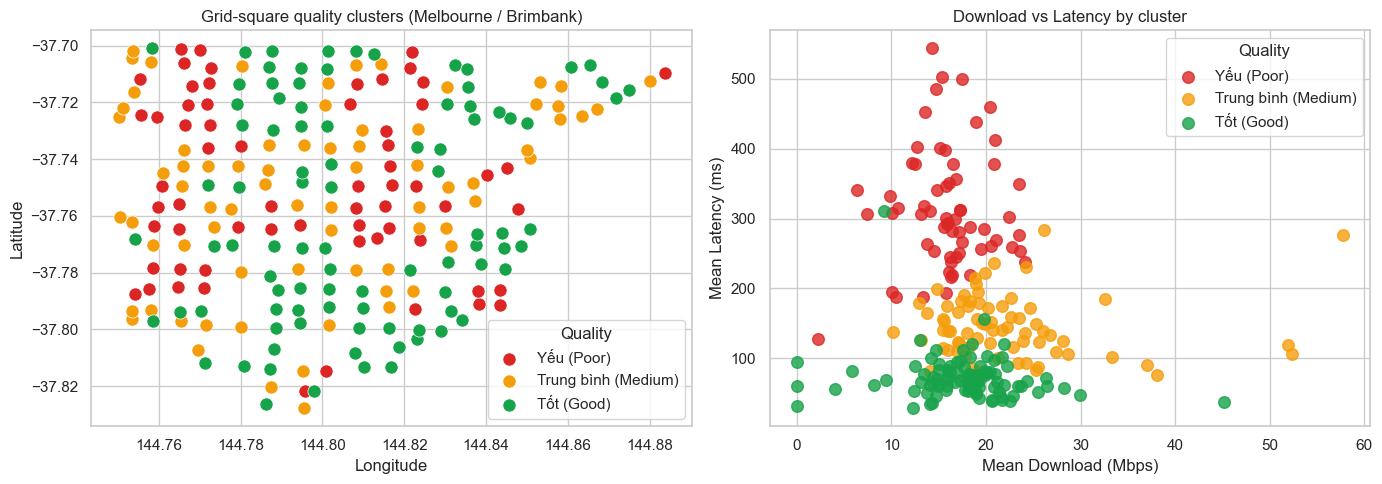

In [10]:
# ── 4a. Spatial scatter + Download vs Latency ─────────────
COLOURS = {0: "#dc2626", 1: "#f59e0b", 2: "#17a34a"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cid, grp in grid.groupby("cluster"):
    axes[0].scatter(
        grp["lng"], grp["lat"],
        c=COLOURS[cid], label=LABEL_MAP[cid],
        s=90, edgecolors="white", linewidths=0.5,
    )
axes[0].set(title="Grid-square quality clusters (Melbourne / Brimbank)",
            xlabel="Longitude", ylabel="Latitude")
axes[0].legend(title="Quality")

for cid, grp in grid.groupby("cluster"):
    axes[1].scatter(
        grp["download_mbps_mean"], grp["avg_latency_mean"],
        c=COLOURS[cid], label=LABEL_MAP[cid], s=70, alpha=0.8,
    )
axes[1].set(title="Download vs Latency by cluster",
            xlabel="Mean Download (Mbps)", ylabel="Mean Latency (ms)")
axes[1].legend(title="Quality")

fig.tight_layout()
plt.show()

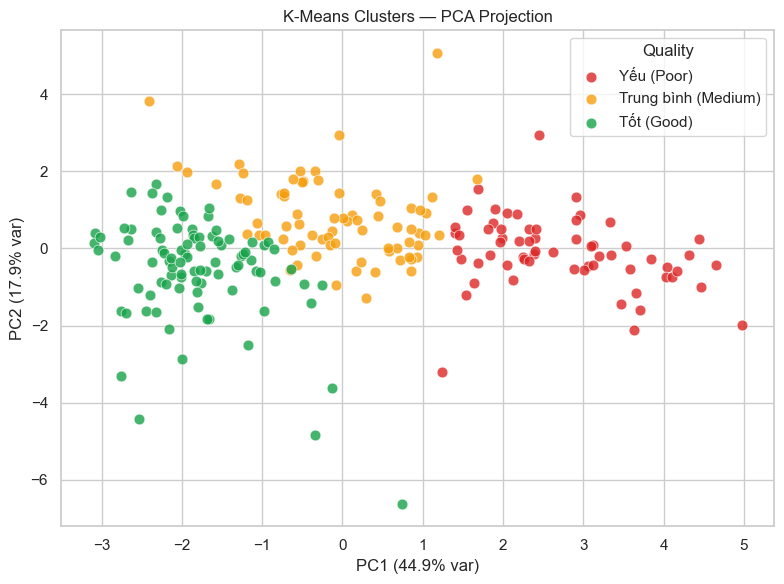

PCA total explained variance: 62.8%


In [11]:
# ── 4b. PCA 2-D projection ────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cid in sorted(grid["cluster"].unique()):
    mask = grid["cluster"] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLOURS[cid], label=LABEL_MAP[cid],
               s=60, edgecolors="white", linewidths=0.5, alpha=0.8)
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)",
       title="K-Means Clusters — PCA Projection")
ax.legend(title="Quality")
fig.tight_layout()
plt.show()

print(f"PCA total explained variance: {pca.explained_variance_ratio_.sum():.1%}")

---
## Step 5 — Export (Frontend Contract)

In [12]:
# ── 5a. Export map_data.csv  (frontend contract: lat, lng, cluster) ──
map_df = grid[["lat", "lng", "cluster"]].copy()
map_path = OUTPUT_DIR / "map_data.csv"
map_df.to_csv(map_path, index=False)

print(f"✓ {map_path}  ({len(map_df)} rows)")
print(f"  Columns : {list(map_df.columns)}")
print(f"  Clusters: {dict(map_df['cluster'].value_counts().sort_index())}")

# ── 5b. Export model artefacts ────────────────────────────
joblib.dump(kmeans, MODELS_DIR / "clustering_model.pkl")
joblib.dump(scaler, MODELS_DIR / "clustering_scaler.pkl")
print(f"✓ clustering_model.pkl  → {MODELS_DIR.resolve()}")
print(f"✓ clustering_scaler.pkl → {MODELS_DIR.resolve()}")

map_df.head()

✓ data\map_data.csv  (227 rows)
  Columns : ['lat', 'lng', 'cluster']
  Clusters: {0: np.int64(63), 1: np.int64(73), 2: np.int64(91)}
✓ clustering_model.pkl  → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models
✓ clustering_scaler.pkl → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models


,lat,lng,cluster
0,-37.725316,144.750162,1
1,-37.724990,144.759573,0
2,-37.727866,144.766303,0
3,-37.727805,144.772520,0
4,-37.728114,144.780211,2


In [13]:
# ── 5c. Cluster distribution summary ──────────────────────
label_map = {0: "Poor / Yếu", 1: "Medium / Trung bình", 2: "Good / Tốt"}

summary = grid.groupby("cluster")[CLUSTER_FEATURES].mean().round(3)
summary.index = summary.index.map(label_map)
print("=== Per-Cluster Feature Means ===")
print(summary.to_string())
print()
print(f"Silhouette Score: {sil:.4f}")
print(f"Total grid squares: {len(grid)}")
for c in sorted(grid["cluster"].unique()):
    n = (grid["cluster"] == c).sum()
    print(f"  Cluster {c} ({label_map[c]}): {n} squares ({100*n/len(grid):.1f}%)")

=== Per-Cluster Feature Means ===
                     download_mbps_mean  download_mbps_std  avg_latency_mean  avg_latency_std  cwnd_mean  retransmission_rate_mean  jitter_mean  latency_spread_mean  congestion_indicator_mean
cluster                                                                                                                                                                                        
Poor / Yếu                       15.999             11.348           312.384          263.427      0.008                     0.140       61.890               40.832                      0.144
Medium / Trung bình              22.215             15.020           145.208          171.297      0.010                     0.202       37.642               47.154                      0.038
Good / Tốt                       17.581             12.348            73.050           75.402      0.013                     0.283       17.157               43.097                      0.022

Silho

In [14]:
# ── 5c. Verification ──────────────────────────────────────
check = pd.read_csv(map_path)
assert list(check.columns) == ["lat", "lng", "cluster"], \
    f"Column mismatch: {list(check.columns)}"
assert set(check["cluster"].unique()) == {0, 1, 2}, \
    f"Missing cluster labels: {check['cluster'].unique()}"
assert len(check) == df["square_id"].nunique(), \
    f"Row count {len(check)} ≠ square_ids {df['square_id'].nunique()}"

model_check = joblib.load(MODELS_DIR / "clustering_model.pkl")
scaler_check = joblib.load(MODELS_DIR / "clustering_scaler.pkl")
assert model_check.n_clusters == 3
assert scaler_check.n_features_in_ == len(CLUSTER_FEATURES)

print(f"✓ map_data.csv verified: {len(check)} rows, columns {list(check.columns)}")
print(f"✓ Model artefacts verified (3 clusters, {len(CLUSTER_FEATURES)} features)")
print(f"  Silhouette score: {sil:.3f}")

✓ map_data.csv verified: 227 rows, columns ['lat', 'lng', 'cluster']
✓ Model artefacts verified (3 clusters, 9 features)
  Silhouette score: 0.208
